In [1]:
import pandas as pd
import numpy as np

import shap
import joblib
import os

from sklearn.model_selection import train_test_split
from scipy import sparse

In [2]:
df = pd.read_csv("../data/application_train.csv")

xgb_model = joblib.load("../outputs/xgboost_model.pkl")

In [3]:
y = df["TARGET"]

X = df.drop(columns=["TARGET", "SK_ID_CURR"])

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [5]:
preprocessor = xgb_model.named_steps["preprocessor"]
classifier = xgb_model.named_steps["classifier"]

In [6]:
X_sample = X_test.sample(n=2000, random_state=42)
y_sample = y_test.loc[X_sample.index]

X_sample.shape

(2000, 120)

In [11]:
if sparse.issparse(X_sample_transformed):
    X_sample_transformed = X_sample_transformed.toarray()

In [12]:
feature_names = preprocessor.get_feature_names_out()

len(feature_names)

244

In [13]:
feature_names[:20]

array(['num__CNT_CHILDREN', 'num__AMT_INCOME_TOTAL', 'num__AMT_CREDIT',
       'num__AMT_ANNUITY', 'num__AMT_GOODS_PRICE',
       'num__REGION_POPULATION_RELATIVE', 'num__DAYS_BIRTH',
       'num__DAYS_EMPLOYED', 'num__DAYS_REGISTRATION',
       'num__DAYS_ID_PUBLISH', 'num__OWN_CAR_AGE', 'num__FLAG_MOBIL',
       'num__FLAG_EMP_PHONE', 'num__FLAG_WORK_PHONE',
       'num__FLAG_CONT_MOBILE', 'num__FLAG_PHONE', 'num__FLAG_EMAIL',
       'num__CNT_FAM_MEMBERS', 'num__REGION_RATING_CLIENT',
       'num__REGION_RATING_CLIENT_W_CITY'], dtype=object)

In [14]:
explainer = shap.TreeExplainer(classifier)

In [15]:
shap_values = explainer.shap_values(X_sample_transformed)

In [16]:
shap_values.shape

(2000, 244)

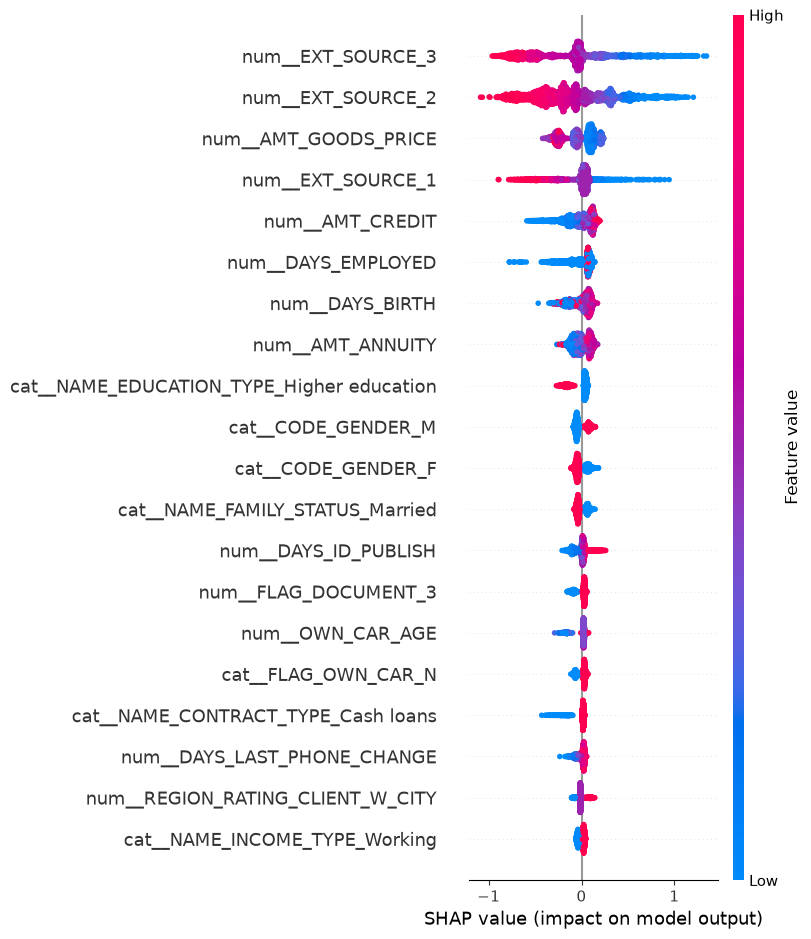

In [17]:
shap.summary_plot(
    shap_values,
    X_sample_transformed,
    feature_names=feature_names,
    max_display=20
)

In [18]:
shap_importance = pd.DataFrame({
    "feature": feature_names,
    "mean_abs_shap": np.abs(shap_values).mean(axis=0)
}).sort_values("mean_abs_shap", ascending=False)

shap_importance.head(20)

,feature,mean_abs_shap
29,num__EXT_SOURCE_3,0.378012
28,num__EXT_SOURCE_2,0.348220
4,num__AMT_GOODS_PRICE,0.142182
27,num__EXT_SOURCE_1,0.140797
2,num__AMT_CREDIT,0.112685
7,num__DAYS_EMPLOYED,0.104787
6,num__DAYS_BIRTH,0.086288
3,num__AMT_ANNUITY,0.072306
129,cat__NAME_EDUCATION_TYPE_Higher education,0.070391
107,cat__CODE_GENDER_M,0.061033


In [19]:
os.makedirs("../outputs", exist_ok=True)

shap_importance.to_csv("../outputs/shap_feature_importance.csv", index=False)

In [20]:
os.path.exists("../outputs/shap_feature_importance.csv")

True

In [26]:
applicant_id = 0

single_applicant = X_sample.iloc[[applicant_id]]
single_applicant

,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
14343,Cash loans,M,Y,Y,0,270000.0,1031053.5,34204.5,783000.0,Unaccompanied,...,0,0,0,0,0.0,0.0,0.0,2.0,0.0,3.0


In [27]:
single_probability = xgb_model.predict_proba(single_applicant)[:, 1][0]

single_probability

np.float32(0.54376286)

In [28]:
def probability_to_score(probability, min_score=300, max_score=850):
    score = max_score - probability * (max_score - min_score)
    return int(round(score))

In [29]:
single_score = probability_to_score(single_probability)

single_score

551

In [30]:
def base_credit_decision(score):
    if score >= 700:
        return "Approve"
    elif score >= 600:
        return "Manual Review"
    else:
        return "Reject"

In [31]:
single_decision = base_credit_decision(single_score)

single_decision

'Reject'

In [32]:
pd.DataFrame({
    "default_probability": [single_probability],
    "credit_score": [single_score],
    "base_decision": [single_decision]
})

,default_probability,credit_score,base_decision
0,0.543763,551,Reject


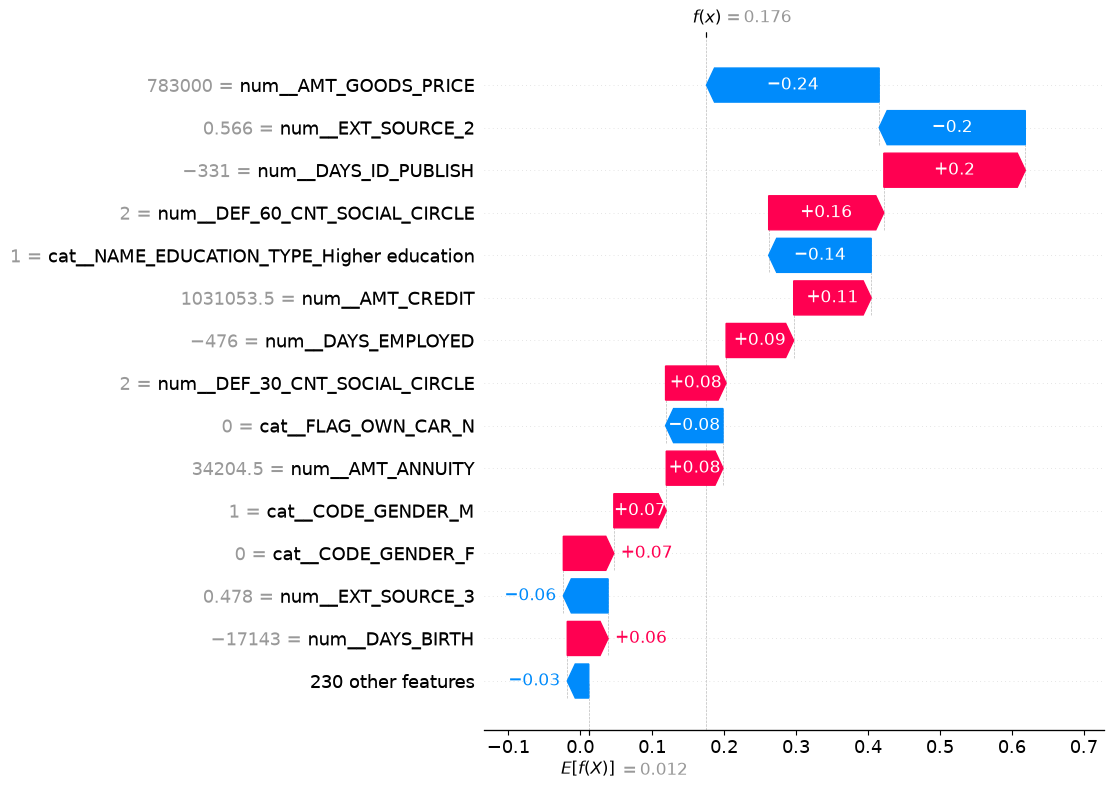

In [33]:
shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[applicant_id],
        base_values=explainer.expected_value,
        data=X_sample_transformed[applicant_id],
        feature_names=feature_names
    ),
    max_display=15
)

## SHAP explainability results

This notebook adds an explainability layer to the Credit Intelligence Engine using SHAP values.

The XGBoost model was explained using TreeSHAP. The global SHAP summary plot shows which features had the largest impact on the model's default risk predictions. Features with higher mean absolute SHAP values contribute more strongly to the model output.

A local explanation was also generated for an individual applicant. The waterfall plot shows which variables increased or decreased the predicted default risk for that specific applicant.

This step improves the interpretability of the credit risk model. Instead of only producing a default probability, credit score, and decision, the engine can now provide feature-level explanations for model behavior.